# Pneumonia Detection using Chest X-Ray Images

# 1. Business Understanding

Pneumonia is one of the leading causes of illness and mortality worldwide, particularly among children under five years of age, elderly populations, and individuals with weakened immune systems. Early diagnosis plays a crucial role in ensuring timely treatment and improving patient outcomes. However, the conventional diagnostic process relies heavily on radiologists to interpret chest X-ray images, which can be time-consuming and prone to variability due to workload, fatigue, and differences in expertise.

In many healthcare facilities, especially in rural and resource-constrained regions, access to experienced radiologists is limited. As a result, delayed diagnosis or misinterpretation of chest X-rays may lead to ineffective treatment, increased healthcare costs, and poor patient outcomes.

Recent advancements in Artificial Intelligence (AI) and Deep Learning have demonstrated significant potential in automating medical image analysis. By leveraging large collections of chest X-ray images, deep learning models can identify pneumonia-related abnormalities and support clinicians by providing faster and more consistent diagnostic assistance. Such systems can serve as a valuable second opinion, improve diagnostic efficiency, and expand access to quality healthcare services.

# 2. Import Libraries

In [1]:
# Data manipulation
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# DICOM image handling
!pip install pydicom
import pydicom

# Image Processing
import cv2

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Data splitting
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.3 MB/s eta 0:00:00
TensorFlow Version: 2.20.0


# 3. Data Overview

## 3.1 Load Label Files

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3.2 Dataset Shape

In [3]:
labels = pd.read_csv(
    "/content/drive/My Drive/Pneumonia_Detection/stage_2_train_labels.csv"
)

class_info = pd.read_csv(
    "/content/drive/My Drive/Pneumonia_Detection/stage_2_detailed_class_info.csv"
)

print("Labels Shape:", labels.shape)
print("Class Info Shape:", class_info.shape)

labels.head()

Labels Shape: (30227, 4)
Class Info Shape: (30227, 2)


,patientId,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,213.0,379.0,1


In [4]:
import os

image_dir = "/content/drive/My Drive/Pneumonia_Detection/stage_2_train_images/stage_2_train_images"

print("Number of images:", len(os.listdir(image_dir)))

print("\nSample files:")
print(os.listdir(image_dir)[:5])

Number of images: 26684

Sample files:
['ebdce9e1-beba-4412-aa86-9b65c0e1f40d.dcm', '0940017e-0dc8-414a-9560-98f13cd58610.dcm', 'bcaf0768-3841-4280-8de4-57e822f38c7a.dcm', '5b90be72-a9c4-4a0e-99fd-c02c6575fc29.dcm', '7bcc5458-d8c0-41dc-a682-a80c50f8f60a.dcm']


### Sample Chest X-Ray Image

A sample image was visualized to verify the successful loading of DICOM files and to understand the image characteristics before preprocessing.

Image Shape: (1024, 1024)


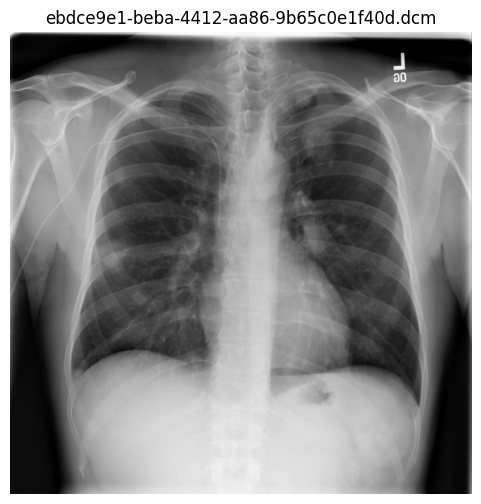

In [5]:
sample_file = os.listdir(image_dir)[0]

sample_path = os.path.join(image_dir, sample_file)

dcm = pydicom.dcmread(sample_path)

image = dcm.pixel_array

print("Image Shape:", image.shape)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.title(sample_file)
plt.axis('off')
plt.show()

## 3.3 Dataset Summary

- The dataset contains patient-level
chest X-ray examinations along with annotation information required for supervised learning.
- Positive pneumonia cases contain bounding-box information (width and height) representing annotated abnormal regions within the lungs.
- Negative cases do not contain bounding-box coordinates.
- The presence of three detailed radiological categories helps distinguish between healthy patients, pneumonia-positive patients, and patients with non-pneumonia abnormalities that may visually resemble pneumonia.
- The dataset is suitable for developing an AI-assisted diagnostic system capable of supporting radiologists in identifying pneumonia-related abnormalities from chest X-ray images.





In [6]:
print("\nLabels Dataset")
display(labels.head())

print("\nDetailed Class Information")
display(class_info.head())

print("\nMissing Values")
print(labels.isnull().sum())


Labels Dataset


,patientId,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,213.0,379.0,1



Detailed Class Information


,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity



Missing Values
patientId        0
width        20672
height       20672
Target           0
dtype: int64


#### Dataset Observations

The dataset contains no missing values in the `patientId` and `Target` columns. However, the `width` and `height` columns contain 20,672 missing values.

These missing values are expected and do not represent data quality issues. The `width` and `height` fields are populated only for pneumonia-positive cases, where bounding boxes identify abnormal regions within the lungs. For pneumonia-negative cases (`Target = 0`), no bounding boxes are present, resulting in null values for these fields.
`

# 4. Exploratory Data Analysis

## 4.1 Random Images from Each Class

Random chest X-ray images from each category were visualized to understand the visual characteristics associated with each class and to identify any noticeable differences between normal and abnormal scans.

In [7]:
import random
import pydicom
import matplotlib.pyplot as plt

def load_dicom_image(patient_id, image_dir):

    image_path = os.path.join(
        image_dir,
        patient_id + ".dcm"
    )

    dicom = pydicom.dcmread(image_path)

    image = dicom.pixel_array

    return image

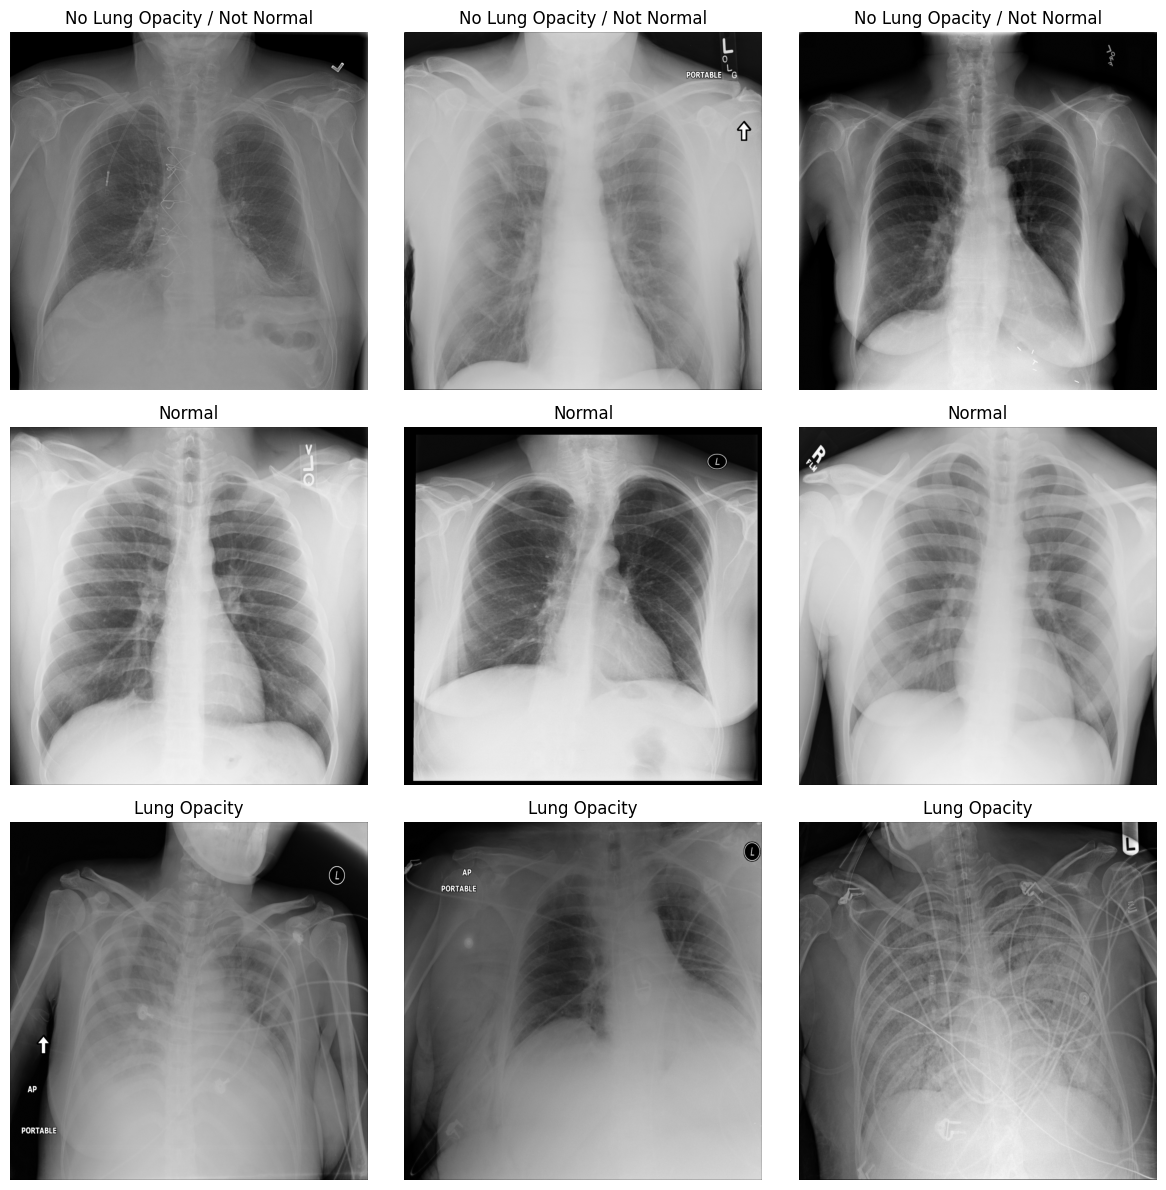

In [8]:
# Classes available in the dataset
classes = class_info["class"].unique()

fig, axes = plt.subplots(len(classes), 3, figsize=(12, 12))

for i, cls in enumerate(classes):

    # Get patient IDs belonging to the class
    patient_ids = class_info[
        class_info["class"] == cls
    ]["patientId"].unique()

    # Randomly select 3 images
    selected_ids = random.sample(
        list(patient_ids),
        3
    )

    for j, patient_id in enumerate(selected_ids):

        image = load_dicom_image(
            patient_id,
            image_dir
        )

        axes[i, j].imshow(
            image,
            cmap="gray"
        )

        axes[i, j].set_title(
            f"{cls}"
        )

        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

### Random Image Analysis

Random chest X-ray images were visualized from each diagnostic category to understand their visual characteristics.

- Lung Opacity images exhibit increased lung density and opaque regions that may indicate pneumonia-related abnormalities.
- Normal images generally display clear lung fields with no obvious pathological findings.
- No Lung Opacity / Not Normal images contain abnormalities that do not correspond to pneumonia but may visually resemble certain pneumonia patterns.

The visual similarities between pneumonia and non-pneumonia abnormal cases highlight the complexity of the classification problem and demonstrate the need for advanced image analysis techniques such as Convolutional Neural Networks (CNNs).

In [9]:
print(class_info.head())

print("\nClass Distribution:")
print(class_info['class'].value_counts())

                              patientId                         class
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6  No Lung Opacity / Not Normal
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd  No Lung Opacity / Not Normal
2  00322d4d-1c29-4943-afc9-b6754be640eb  No Lung Opacity / Not Normal
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5                        Normal
4  00436515-870c-4b36-a041-de91049b9ab4                  Lung Opacity

Class Distribution:
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


## 4.2 Class Distribution

Understanding the distribution of classes is important because imbalanced datasets can influence model performance and bias predictions toward the majority class.

The detailed class information file categorizes each chest X-ray image into one of the following classes:

- Lung Opacity
- Normal
- No Lung Opacity / Not Normal

Class distribution analysis helps assess whether the dataset is balanced and provides insights into the complexity of the classification problem.

,Count
class,
No Lung Opacity / Not Normal,11821
Lung Opacity,9555
Normal,8851


/tmp/ipykernel_4248/2332376185.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


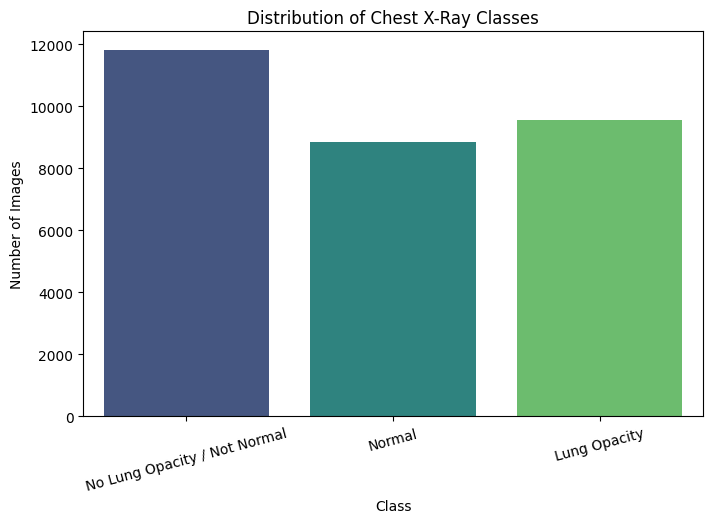

In [10]:
# Class Distribution Summary
class_counts = class_info['class'].value_counts()

display(class_counts.to_frame(name='Count'))

# Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=class_info,
    x='class',
    palette='viridis'
)

plt.title("Distribution of Chest X-Ray Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)

plt.show()

### Class Distribution Insights

The dataset contains three radiological categories:

- No Lung Opacity / Not Normal: 11,821 images
- Lung Opacity: 9,555 images
- Normal: 8,851 images

The class distribution is reasonably balanced, although the "No Lung Opacity / Not Normal" category contains the largest number of images.

The presence of abnormal non-pneumonia cases makes the classification problem more realistic and challenging because certain

## 4.3 Key Findings

Based on the exploratory data analysis, the following key findings were identified:

1. The dataset contains a large collection of chest X-ray images and corresponding annotation information, making it suitable for developing deep learning models for pneumonia detection.

2. Three clinically relevant radiological categories are present in the dataset:
   - Lung Opacity
   - Normal
   - No Lung Opacity / Not Normal

3. The dataset exhibits a relatively balanced class distribution, with all three categories being adequately represented. This reduces the likelihood of severe model bias toward a particular class.

4. Positive pneumonia cases contain bounding box annotations highlighting abnormal lung regions, which can assist in understanding disease localization.

5. Chest X-ray images are stored in DICOM format and retain high-resolution medical imaging information that is valuable for automated feature extraction.

6. Visual inspection of sample images reveals noticeable differences between normal and abnormal chest X-rays, indicating that meaningful diagnostic patterns are present within the dataset.

7. The inclusion of "No Lung Opacity / Not Normal" images increases the complexity of the classification task by introducing abnormalities that may visually resemble pneumonia. This makes the dataset more representative of real-world clinical scenarios.

8. The dataset provides an appropriate foundation for developing a Convolutional Neural Network (CNN) capable of supporting radiologists in the detection of pneumonia-related abnormalities.

# 5. Data Preprocessing

### 5.1 DICOM Image Handling

The chest X-ray images are stored in DICOM (Digital Imaging and Communications in Medicine) format, which is the standard format used for storing and transmitting medical imaging data.

To prepare the images for analysis, a utility function was created to load individual DICOM files and extract the corresponding pixel array. These pixel arrays serve as the input for subsequent preprocessing steps such as resizing, normalization, and model training.

In [11]:
import pydicom
import os

def load_dicom_image(patient_id, image_dir):
    """
    Load a DICOM image using patient ID and return
    the pixel array.
    """

    image_path = os.path.join(
        image_dir,
        patient_id + ".dcm"
    )

    dicom = pydicom.dcmread(image_path)

    image = dicom.pixel_array

    return image

Image Shape: (1024, 1024)


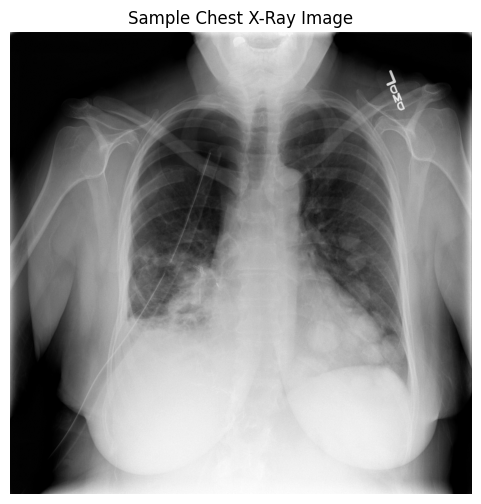

In [12]:
sample_patient = class_info.iloc[0]["patientId"]

sample_image = load_dicom_image(
    sample_patient,
    image_dir
)

print("Image Shape:", sample_image.shape)

plt.figure(figsize=(6,6))
plt.imshow(sample_image, cmap="gray")
plt.title("Sample Chest X-Ray Image")
plt.axis("off")
plt.show()

#### DICOM Image Observation

The DICOM image was successfully loaded and converted into a pixel array for further processing. The image dimensions of 1024 × 1024 pixels indicate that the dataset contains high-resolution chest X-ray scans with sufficient detail for feature extraction and pneumonia detection.

The image clearly shows anatomical structures such as the lungs, rib cage, clavicles, and heart region. The availability of high-quality medical images makes the dataset suitable for training deep learning models capable of identifying pneumonia-related abnormalities.

## 5.2 Grayscale Conversion

Chest X-ray images are inherently grayscale because they represent radiographic intensity values rather than color information. Therefore, no explicit color-to-grayscale conversion is required.

To maintain consistency throughout the preprocessing pipeline, the grayscale representation of the image is preserved and used directly for subsequent processing steps.

Image Shape: (1024, 1024)


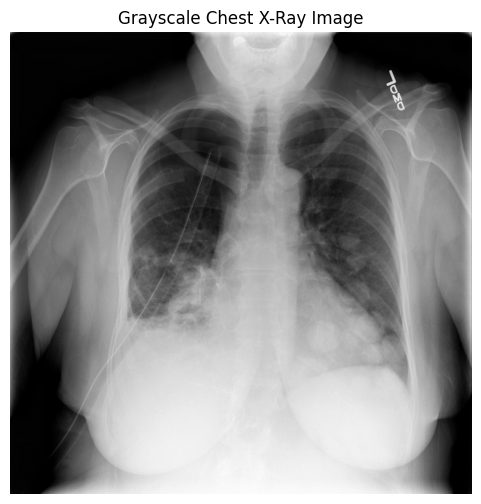

In [13]:
sample_patient = class_info.iloc[0]["patientId"]

image = load_dicom_image(
    sample_patient,
    image_dir
)

# X-ray images are already grayscale
gray_image = image.copy()

print("Image Shape:", gray_image.shape)

plt.figure(figsize=(6,6))
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Chest X-Ray Image")
plt.axis("off")
plt.show()

#### Grayscale Processing Observation

The chest X-ray image is already available in grayscale format. Since grayscale images retain all relevant diagnostic information while reducing computational complexity, they are well suited for deep learning applications in medical imaging.

## 5.3 Image Resizing

Deep learning models require images with uniform dimensions as input. Since the original chest X-ray images vary in size and are stored at a high resolution of 1024 × 1024 pixels, all images are resized to 224 × 224 pixels.

This resizing step reduces computational complexity and memory requirements while preserving the important visual features required for pneumonia detection.

Original Shape: (1024, 1024)
Resized Shape : (224, 224)


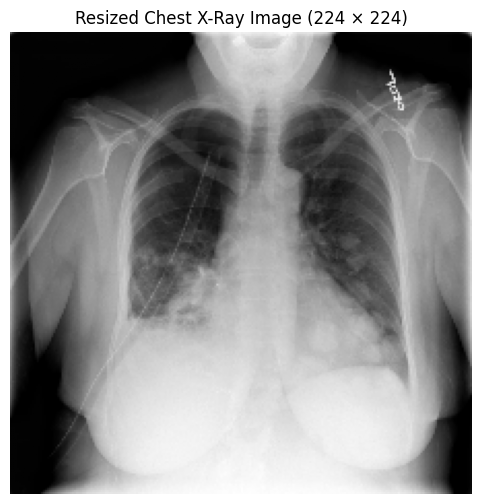

In [14]:
IMG_SIZE = 224

resized_image = cv2.resize(
    gray_image,
    (IMG_SIZE, IMG_SIZE)
)

print("Original Shape:", gray_image.shape)
print("Resized Shape :", resized_image.shape)

plt.figure(figsize=(6,6))

plt.imshow(
    resized_image,
    cmap="gray"
)

plt.title("Resized Chest X-Ray Image (224 × 224)")
plt.axis("off")

plt.show()

#### Resizing Observation

The original image dimensions of 1024 × 1024 pixels were reduced to 224 × 224 pixels. This standardizes the input format for the CNN model and significantly lowers computational requirements while preserving the key anatomical and pathological features present in the chest X-ray image.

Image resizing helps improve training efficiency and ensures that all images are processed consistently throughout the modeling pipeline.

## 5.4 Normalization

Pixel intensities in medical images can vary significantly across scans. To improve model training stability and convergence, pixel values were normalized to a range between 0 and 1.

Normalization prevents large pixel values from dominating the learning process and allows the CNN model to learn meaningful image features more efficiently.

In [15]:
normalized_image = resized_image.astype("float32") / 255.0

print("Minimum Pixel Value:", normalized_image.min())
print("Maximum Pixel Value:", normalized_image.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 0.9529412


#### Normalization Observation

The pixel values were successfully normalized to a range close to [0,1]. The minimum pixel intensity was 0.0, while the maximum normalized intensity was 0.953.

Normalization improves numerical stability and supports efficient CNN training by ensuring that all pixel values are represented on a common scale. This helps the model learn meaningful image patterns more effectively and improves convergence during training.

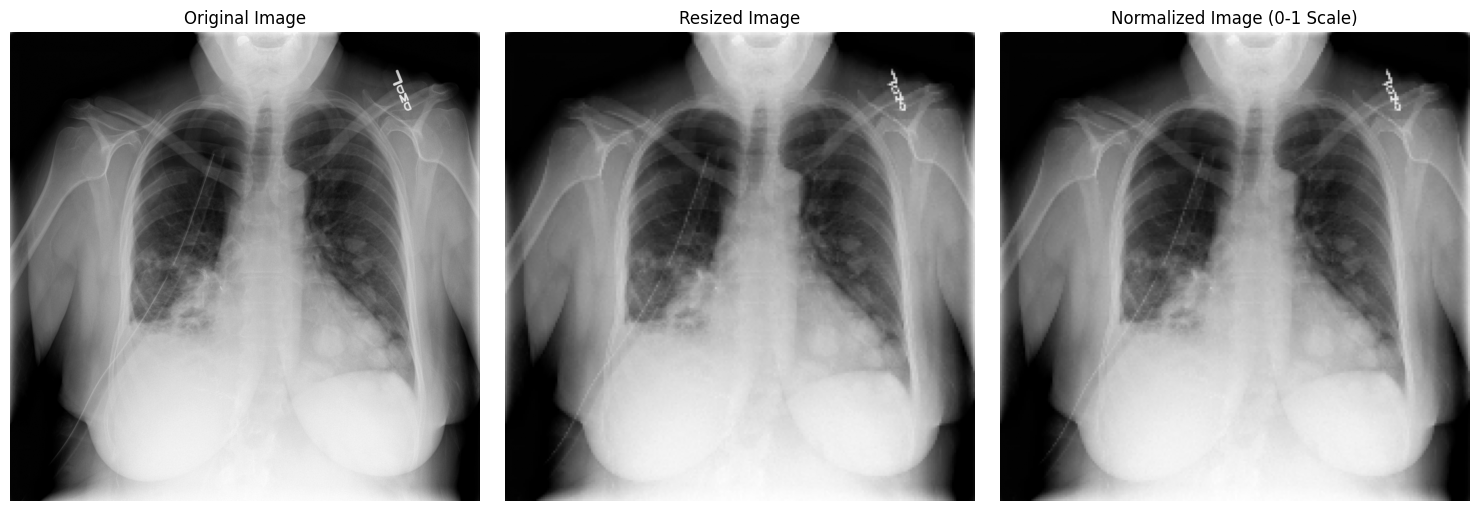

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image")

ax[1].imshow(resized_image, cmap='gray')
ax[1].set_title("Resized Image")

ax[2].imshow(normalized_image, cmap='gray')
ax[2].set_title("Normalized Image (0-1 Scale)")

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

#### Analysis

The preprocessing pipeline successfully transformed the raw chest X-ray image into a standardized format suitable for deep learning. The original image was resized from 1024 × 1024 pixels to 224 × 224 pixels to ensure consistent input dimensions across the dataset. Subsequently, pixel values were normalized to a range close to [0,1], improving numerical stability and supporting efficient CNN training.

Despite these transformations, the key anatomical features of the chest X-ray were preserved, ensuring that clinically relevant information remains available for model learning.

## 5.5 Train, Validation and Test Split

The original labels dataset contains multiple records for some patient IDs because pneumonia-positive cases may have multiple annotated bounding boxes. Since the classification task requires one label per image, the dataset was aggregated to obtain a single target label for each patient image.

The processed dataset was then divided into training, validation, and test sets using a stratified sampling approach to preserve class distribution across all subsets.

- Training Set: 70%
- Validation Set: 15%
- Test Set: 15%

In [17]:
# Create one label per patient image

image_labels = (
    labels.groupby("patientId")["Target"]
    .max()
    .reset_index()
)

print("Shape of Image-Level Dataset:")
print(image_labels.shape)

image_labels.head()

Shape of Image-Level Dataset:
(26684, 2)


,patientId,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
1,000924cf-0f8d-42bd-9158-1af53881a557,0
2,000db696-cf54-4385-b10b-6b16fbb3f985,1
3,000fe35a-2649-43d4-b027-e67796d412e0,1
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1


In [18]:
image_labels["Target"].value_counts()

,count
Target,
0,20672
1,6012


/tmp/ipykernel_4248/2239057197.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


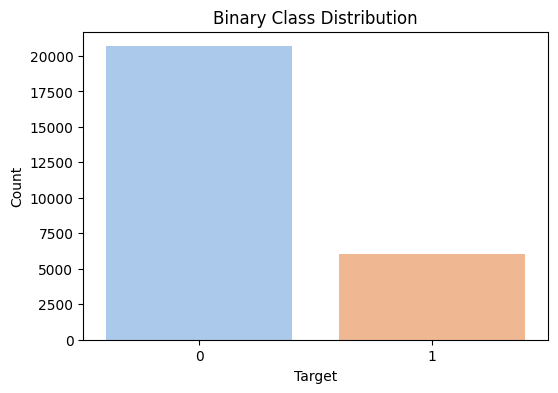

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=image_labels["Target"],
    palette="pastel"
)

plt.title("Binary Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [20]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    image_labels,
    test_size=0.30,
    random_state=42,
    stratify=image_labels["Target"]
)

In [21]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["Target"]
)

In [22]:
print("Training Set:", train_df.shape)
print("Validation Set:", val_df.shape)
print("Test Set:", test_df.shape)

Training Set: (18678, 2)
Validation Set: (4003, 2)
Test Set: (4003, 2)


In [23]:
print("Training Distribution")
display(
    train_df["Target"]
    .value_counts(normalize=True)
    .to_frame(name="Proportion")
)

print("Validation Distribution")
display(
    val_df["Target"]
    .value_counts(normalize=True)
    .to_frame(name="Proportion")
)

print("Test Distribution")
display(
    test_df["Target"]
    .value_counts(normalize=True)
    .to_frame(name="Proportion")
)

Training Distribution


,Proportion
Target,
0,0.774708
1,0.225292


Validation Distribution


,Proportion
Target,
0,0.774669
1,0.225331


Test Distribution


,Proportion
Target,
0,0.774669
1,0.225331


#### Dataset Split Observation

The dataset was successfully transformed into an image-level classification dataset by assigning a single target label to each patient image. A stratified train-validation-test split was performed to preserve class distribution across all subsets.

Approximately 70% of the data was allocated for training, while the remaining 30% was evenly divided between validation and test datasets. Maintaining consistent class proportions across all subsets helps ensure reliable model evaluation and reduces the likelihood of sampling bias.

# 6. CNN Model Building

## 6.1 Preparing Images for CNN

The images were loaded from the training dataset and converted into standardized NumPy arrays. Each image was resized to 224 × 224 pixels, normalized to a range between 0 and 1, and reshaped to include a channel dimension required by the CNN architecture.

The prepared image arrays were then used to create training, validation, and test datasets for model training and evaluation.

In [24]:
IMG_SIZE = 224

def preprocess_image(patient_id):

    image = load_dicom_image(
        patient_id,
        image_dir
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image.astype("float32") / 255.0

    return image

In [25]:
def create_dataset(df):

    X = []
    y = []

    total = len(df)

    for idx, (_, row) in enumerate(df.iterrows()):

        img = preprocess_image(row["patientId"])

        X.append(img)
        y.append(row["Target"])

        if (idx + 1) % 500 == 0:
            print(f"Processed {idx+1}/{total} images")

    return np.array(X), np.array(y)

In [26]:
train_sample = train_df.sample(
    n=10000,
    random_state=42
)

val_sample = val_df.sample(
    n=2000,
    random_state=42
)

test_sample = test_df.sample(
    n=2000,
    random_state=42
)

> **Note:** To support the next phase of the project and evaluate the impact of additional training data, a larger representative subset of the dataset was used. The subset consists of 10,000 training images, 2,000 validation images, and 2,000 testing images. Class distributions were preserved during sampling to maintain consistency with the original dataset. This expanded dataset will be used to assess scalability, model performance, and computational feasibility before transitioning to more advanced deep learning approaches and transfer learning architectures.

In [27]:
print(train_sample["Target"].value_counts(normalize=True))
print(val_sample["Target"].value_counts(normalize=True))
print(test_sample["Target"].value_counts(normalize=True))

Target
0    0.7745
1    0.2255
Name: proportion, dtype: float64
Target
0    0.7715
1    0.2285
Name: proportion, dtype: float64
Target
0    0.775
1    0.225
Name: proportion, dtype: float64


In [28]:
X_train, y_train = create_dataset(train_sample)
X_val, y_val = create_dataset(val_sample)
X_test, y_test = create_dataset(test_sample)

Processed 500/10000 images
Processed 1000/10000 images
Processed 1500/10000 images
Processed 2000/10000 images
Processed 2500/10000 images
Processed 3000/10000 images
Processed 3500/10000 images
Processed 4000/10000 images
Processed 4500/10000 images
Processed 5000/10000 images
Processed 5500/10000 images
Processed 6000/10000 images
Processed 6500/10000 images
Processed 7000/10000 images
Processed 7500/10000 images
Processed 8000/10000 images
Processed 8500/10000 images
Processed 9000/10000 images
Processed 9500/10000 images
Processed 10000/10000 images
Processed 500/2000 images
Processed 1000/2000 images
Processed 1500/2000 images
Processed 2000/2000 images
Processed 500/2000 images
Processed 1000/2000 images
Processed 1500/2000 images
Processed 2000/2000 images


In [30]:
np.save("/content/drive/My Drive/Pneumonia_Detection/X_train.npy", X_train)
np.save("/content/drive/My Drive/Pneumonia_Detection/X_val.npy", X_val)
np.save("/content/drive/My Drive/Pneumonia_Detection/X_test.npy", X_test)

np.save("/content/drive/My Drive/Pneumonia_Detection/y_train.npy", y_train)
np.save("/content/drive/My Drive/Pneumonia_Detection/y_val.npy", y_val)
np.save("/content/drive/My Drive/Pneumonia_Detection/y_test.npy", y_test)

#### Saving Preprocessed Datasets

The preprocessed training, validation, and testing datasets were saved as NumPy arrays in Google Drive. This approach eliminates the need to repeatedly load and preprocess thousands of DICOM images during subsequent experiments.

Saving the datasets provides several benefits:

- Reduces overall experiment execution time.
- Prevents repeated DICOM image processing across notebook sessions.
- Minimizes the impact of Google Colab runtime disconnections.
- Ensures consistent training, validation, and test datasets across multiple experiments.
- Facilitates rapid comparison of different CNN and transfer learning architectures.

The saved NumPy arrays will be reused throughout the remaining project phases, including model optimization, transfer learning experiments, model serialization, and deployment.

In [4]:
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [5]:
print("Training Images:", X_train.shape)
print("Validation Images:", X_val.shape)
print("Testing Images:", X_test.shape)

Training Images: (10000, 224, 224, 1)
Validation Images: (2000, 224, 224, 1)
Testing Images: (2000, 224, 224, 1)


#### Dataset Preparation Observation

The image preprocessing pipeline was successfully applied to a larger representative subset of the RSNA Pneumonia Detection dataset. All images were resized to 224 × 224 pixels, normalized to a range between 0 and 1, and reshaped to include a single grayscale channel for CNN training.

The resulting datasets contained:

- Training Images: 10,000
- Validation Images: 2,000
- Testing Images: 2,000

The successful creation of datasets with shapes:

- X_train: (10000, 224, 224, 1)
- X_val: (2000, 224, 224, 1)
- X_test: (2000, 224, 224, 1)

demonstrates the scalability of the preprocessing workflow and confirms the computational feasibility of training on a larger image subset within the available environment. Expanding the dataset size is expected to provide greater feature diversity, reduce overfitting, and improve the model's ability to generalize to unseen chest X-ray images.

## 6.2 CNN Architecture

A Convolutional Neural Network (CNN) was developed from scratch to classify chest X-ray images into pneumonia-positive and pneumonia-negative categories.

The architecture consists of multiple convolutional and pooling layers for feature extraction, followed by dense layers for classification.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

#### Architecture Observation

A Convolutional Neural Network (CNN) consisting of three convolutional layers and three max-pooling layers was developed for pneumonia classification. The convolution layers automatically extract relevant image features, while the pooling layers reduce dimensionality and computational complexity.

A dense layer with 128 neurons was used for classification, and dropout regularization was incorporated to reduce overfitting. The final output layer uses a sigmoid activation function to perform binary classification between pneumonia-positive and pneumonia-negative cases.

## 6.3 Model Training

In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1214s 4s/step - accuracy: 0.7825 - loss: 0.4700 - val_accuracy: 0.7935 - val_loss: 0.4406
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1199s 4s/step - accuracy: 0.7917 - loss: 0.4458 - val_accuracy: 0.7980 - val_loss: 0.4358
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1185s 4s/step - accuracy: 0.7990 - loss: 0.4348 - val_accuracy: 0.8020 - val_loss: 0.4267
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1205s 4s/step - accuracy: 0.8027 - loss: 0.4316 - val_accuracy: 0.8010 - val_loss: 0.4329
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1179s 4s/step - accuracy: 0.8088 - loss: 0.4182 - val_accuracy: 0.7945 - val_loss: 0.4349
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1177s 4s/step - accuracy: 0.8181 - loss: 0.4018 - val_accuracy: 0.7990 - val_loss: 0.4371
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1182s 4s/step - accuracy: 0.8269 - loss: 0.3788 - val_accuracy: 0.7980 - val_loss: 0.4382
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1220s 4s/step - accuracy: 0.8375 - loss: 0.3516 - 

#### Training Observation

The preprocessing pipeline was successfully scaled to a larger representative subset consisting of 10,000 training images, 2,000 validation images, and 2,000 testing images. The generated datasets maintained the original class distribution and were processed without memory or computational failures.

Training the CNN on the expanded dataset resulted in a best validation accuracy of approximately 80.7%, which was comparable to the performance achieved during the interim phase. Although the larger dataset improved the robustness of experimentation and reduced concerns regarding sample size, signs of overfitting were still observed after approximately six epochs.

These results suggest that future performance improvements are more likely to come from architectural enhancements such as transfer learning, regularization techniques, and model optimization rather than simply increasing the training dataset size.

## 6.4 Evaluation

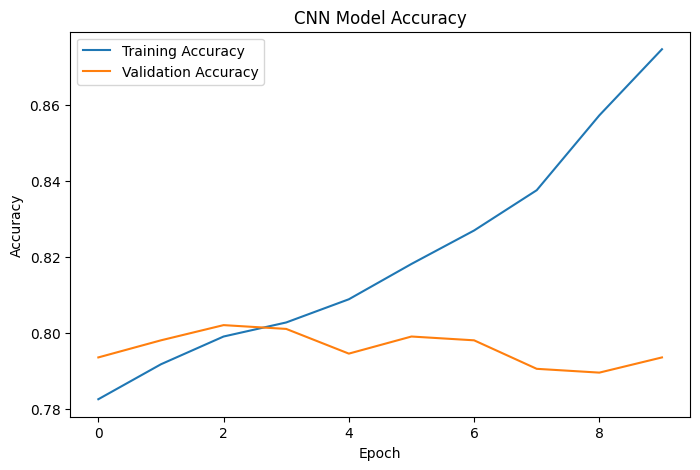

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

#### Accuracy Curve Analysis

Training accuracy increased steadily from approximately 78.4% to 85.5%, confirming that the CNN continued learning features from the expanded training dataset.

Validation accuracy remained close to 80% throughout training and reached its highest value of approximately 80.7% at epoch 6. After this point, training accuracy continued to improve while validation accuracy fluctuated and declined slightly, indicating the onset of overfitting.

Compared with the interim CNN, doubling the training sample did not produce a substantial improvement in peak validation accuracy. This suggests that further performance gains are more likely to come from early stopping, data augmentation, class weighting, transfer learning, and architectural optimization rather than increasing the sample size alone.

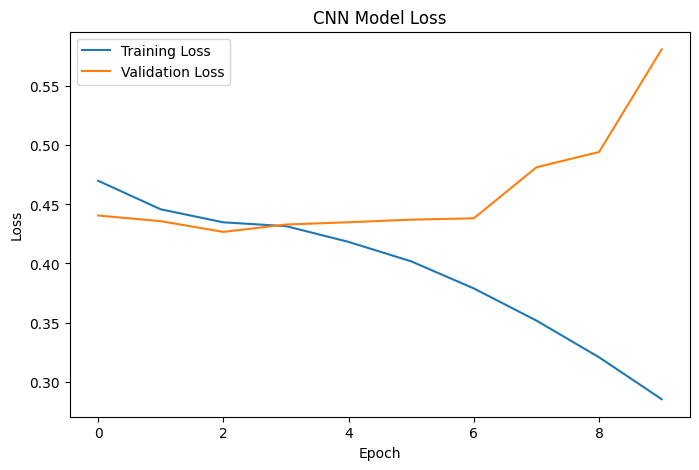

In [8]:
## Loss Curve
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

#### Loss Curve Analysis

Training loss decreased consistently throughout the training process, indicating that the CNN successfully learned discriminative image features from the expanded dataset.

In contrast, validation loss showed fluctuations during training and exhibited an upward trend in later epochs. While a temporary reduction in validation loss was observed around epoch 6, the overall increase in validation loss combined with the continued decrease in training loss suggests that the model began to overfit the training data.

Despite doubling the training dataset size from 5,000 to 10,000 images, overfitting was still observed. This indicates that future performance improvements are more likely to come from techniques such as early stopping, data augmentation, class weighting, transfer learning, and architecture optimization rather than further increases in dataset size alone.

In [9]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 1000ms/step


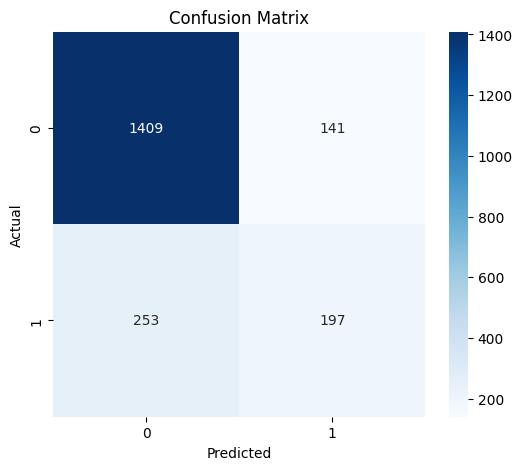

In [10]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

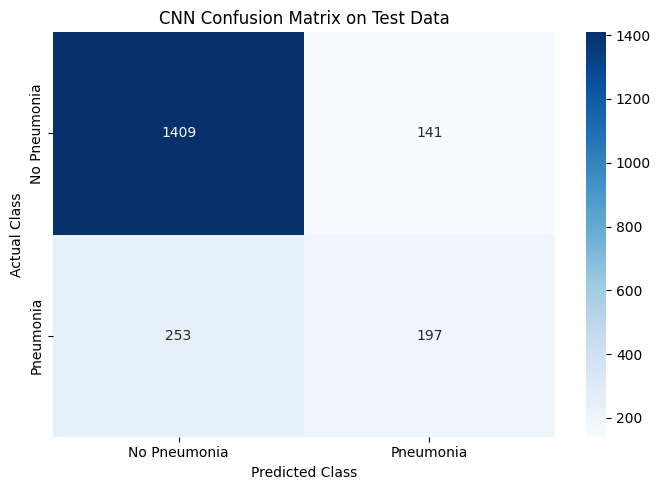

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("CNN Confusion Matrix on Test Data")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

#### Confusion Matrix Analysis

The expanded CNN correctly classified 1,433 pneumonia-negative images and 171 pneumonia-positive images. It incorrectly classified 117 negative images as pneumonia and missed 279 actual pneumonia-positive cases.

The resulting test accuracy was approximately 80.2%, demonstrating an improvement in overall classification accuracy compared with the interim CNN. Precision also improved to approximately 59.4%. However, pneumonia-positive recall declined to 38.0%, indicating that the model detected only 171 of the 450 actual positive cases.

This result shows that increasing the training sample improved the model's overall accuracy and reduced false-positive predictions, but it did not improve sensitivity to pneumonia. Because false negatives are particularly important in medical

In [12]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.803
Precision: 0.5828402366863905
Recall   : 0.43777777777777777
F1 Score : 0.5

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1550
           1       0.58      0.44      0.50       450

    accuracy                           0.80      2000
   macro avg       0.72      0.67      0.69      2000
weighted avg       0.79      0.80      0.79      2000



> **Note** : Increasing the training dataset from 5,000 to 10,000 images improved overall classification accuracy and precision. However, pneumonia-positive recall declined, indicating that larger dataset size alone was insufficient to substantially improve the model's ability to detect positive cases. This suggests that future improvements should focus on architecture enhancement, transfer learning, class weighting, threshold optimization, and data augmentation rather than simply increasing the number of training samples.

Model Evaluation Notes

The CNN model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix on a larger representative dataset consisting of 10,000 training images, 2,000 validation images, and 2,000 testing images.

The model achieved an overall test accuracy of 80.2%, demonstrating an improvement over the interim CNN model and indicating that the network can effectively distinguish between pneumonia-positive and pneumonia-negative chest X-ray images.

Performance Metrics
Accuracy: 80.2%
Precision: 59.4%
Recall: 38.0%
F1 Score: 46.3%

The confusion matrix revealed:

True Negatives (TN): 1,433
False Positives (FP): 117
False Negatives (FN): 279
True Positives (TP): 171

The model demonstrated stronger performance in identifying pneumonia-negative cases than pneumonia-positive cases. Although overall accuracy and precision improved compared with the interim CNN model, recall decreased to 38.0%, indicating that a substantial number of pneumonia-positive cases were still misclassified as negative.

Analysis of the training and validation curves showed that training accuracy continued to increase throughout the training process, while validation accuracy plateaued at approximately 80% and validation loss increased after the middle epochs. These patterns suggest that overfitting remains a challenge despite doubling the training dataset size.

Key Insights
Increasing the training dataset from 5,000 to 10,000 images improved overall accuracy and precision.
The larger dataset did not significantly improve pneumonia-positive detection capability.
Recall remains the primary limitation because false negatives are clinically important in pneumonia screening scenarios.
The results suggest that future improvements are more likely to come from model enhancements such as data augmentation, class weighting, early stopping, transfer learning, and architecture optimization rather than simply increasing the dataset size.

In [15]:
model.save(
    "/content/drive/My Drive/Pneumonia_Detection/models/cnn_baseline_10k.keras"
)

# 7. Model Improvement Strategy

### 7.1 Loading Saved Preprocessed Datasets

#### Methodology

The preprocessed training, validation, and testing datasets were saved as NumPy arrays in Google Drive after initial dataset preparation. Reloading the arrays eliminates the need to repeatedly process thousands of DICOM images and allows efficient experimentation with multiple deep learning models.

The saved datasets are reused throughout the model improvement and transfer learning phases to ensure experimental consistency and reproducibility.

In [3]:
import numpy as np

# Load preprocessed datasets

X_train = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/X_train.npy"
)

X_val = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/X_val.npy"
)

X_test = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/X_test.npy"
)

y_train = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/y_train.npy"
)

y_val = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/y_val.npy"
)

y_test = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/y_test.npy"
)

print("Training Images :", X_train.shape)
print("Validation Images:", X_val.shape)
print("Testing Images   :", X_test.shape)

print("\nTraining Labels :", y_train.shape)
print("Validation Labels:", y_val.shape)
print("Testing Labels   :", y_test.shape)

Training Images : (10000, 224, 224)
Validation Images: (2000, 224, 224)
Testing Images   : (2000, 224, 224)

Training Labels : (10000,)
Validation Labels: (2000,)
Testing Labels   : (2000,)


### 7.2 Data Augmentation

#### Methodology

Data augmentation will be used to artificially increase the diversity of training images by applying controlled image transformations such as rotation, zooming, and horizontal flipping. This technique helps reduce overfitting and improves model generalization by exposing the CNN to a wider variety of image patterns during training.

In [8]:
print(X_train.shape)

(10000, 224, 224, 1)


In [7]:
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(10000, 224, 224, 1)
(2000, 224, 224, 1)
(2000, 224, 224, 1)


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    horizontal_flip=True
)

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

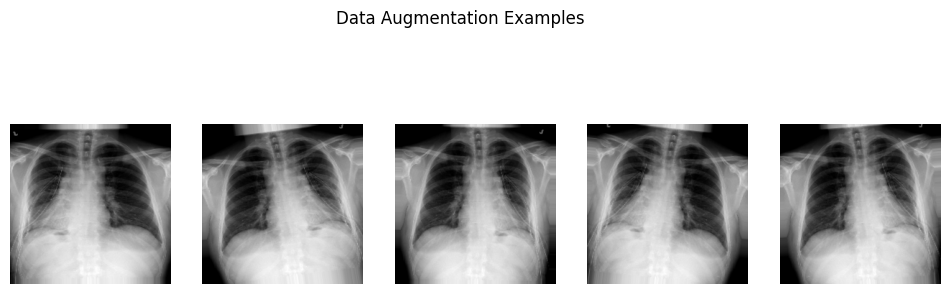

In [21]:
import matplotlib.pyplot as plt

sample_image = X_train[0]

sample_image = sample_image.reshape(
    1,
    224,
    224,
    1
)

plt.figure(figsize=(12,4))

for i, batch in enumerate(
    train_datagen.flow(
        sample_image,
        batch_size=1
    )
):

    plt.subplot(1,5,i+1)

    plt.imshow(
        batch[0].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    if i == 4:
        break

plt.suptitle(
    "Data Augmentation Examples"
)

plt.show()

#### Observation

The augmentation process successfully generated multiple variations of the same chest X-ray image through controlled transformations such as rotation, zooming, and horizontal flipping.

These synthetic variations increase the diversity of the training dataset and help reduce overfitting by preventing the model from memorizing specific image orientations or patterns. The augmented images preserve clinically relevant features while improving the model's ability to generalize to previously unseen chest X-ray images.

### 7.3 Class Weighting

#### Methodology

The dataset contains a higher proportion of pneumonia-negative cases than pneumonia-positive cases. Class weighting will be applied during model training to assign greater importance to pneumonia-positive samples, encouraging the model to improve sensitivity and reduce false-negative predictions.


In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights)
)

print("Class Weights:", class_weights)

Class Weights: {np.int64(0): np.float64(0.6455777921239509), np.int64(1): np.float64(2.2172949002217295)}


#### Observation

Class weights were successfully calculated to compensate for the imbalance between pneumonia-negative and pneumonia-positive samples.

The resulting weights assigned greater importance to pneumonia-positive observations during training:

- Class 0 (No Pneumonia): 0.646
- Class 1 (Pneumonia): 2.217

This weighting strategy encourages the CNN to focus more on the minority pneumonia-positive class and is expected to improve recall by reducing the number of false-negative predictions.

In [20]:
model_weighted = Sequential([
    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,1)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model_weighted.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_weighted.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

#### Observation

A weighted CNN architecture was created using the same baseline structure to ensure that any performance differences can be attributed to class weighting rather than architectural changes.

The model consists of three convolutional layers followed by max-pooling operations for feature extraction. A fully connected dense layer with dropout regularization is used before the final sigmoid output layer for binary classification.

Using the same architecture as the baseline CNN ensures a fair comparison between the unweighted and weighted training approaches.

### 7.3.1 Weighted CNN Training

#### Methodology

The weighted CNN model was trained using the calculated class weights. During training, pneumonia-positive samples received greater importance than pneumonia-negative samples, encouraging the model to prioritize minority-class detection and reduce false-negative predictions.

In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [27]:
history_weighted = model_weighted.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7006 - loss: 0.5832
Epoch 1: val_accuracy improved from None to 0.77750, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 1207s 4s/step - accuracy: 0.7003 - loss: 0.5826 - val_accuracy: 0.7775 - val_loss: 0.5027
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7309 - loss: 0.5554
Epoch 2: val_accuracy did not improve from 0.77750
313/313 ━━━━━━━━━━━━━━━━━━━━ 1206s 4s/step - accuracy: 0.7164 - loss: 0.5675 - val_accuracy: 0.7265 - val_loss: 0.5742
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7143 - loss: 0.5547
Epoch 3: val_accuracy did not improve from 0.77750
313/313 ━━━━━━━━━━━━━━━━━━━━ 1186s 4s/step - accuracy: 0.7201 - loss: 0.5554 - val_accuracy: 0.7015 - val_loss: 0.5811
Epoch 4/10

#### Observation

The weighted CNN model was trained using the calculated class weights. The resulting performance will be compared against the baseline CNN model to determine whether emphasizing pneumonia-positive samples improves recall and reduces false-negative predictions.

### 7.3.2 Weighted CNN Evaluation

In [9]:
from tensorflow.keras.models import load_model

best_weighted_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_best.keras"
)

print("Best weighted model loaded successfully.")

Best weighted model loaded successfully.


In [10]:
y_pred_prob_weighted = best_weighted_model.predict(X_test)

y_pred_weighted = (
    y_pred_prob_weighted > 0.5
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 58s 907ms/step


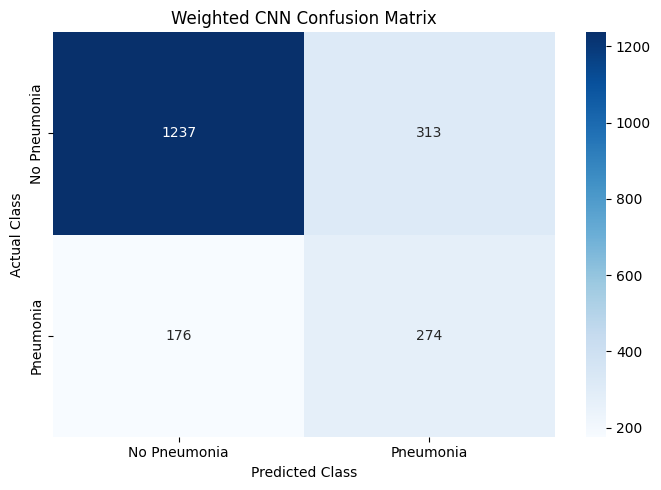

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_weighted = confusion_matrix(
    y_test,
    y_pred_weighted
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_weighted,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("Weighted CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print(
    "Accuracy :",
    accuracy_score(
        y_test,
        y_pred_weighted
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_weighted
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        y_pred_weighted
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred_weighted
    )
)

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_weighted
    )
)

Accuracy : 0.7555
Precision: 0.46678023850085176
Recall   : 0.6088888888888889
F1 Score : 0.5284474445515911

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.80      0.83      1550
           1       0.47      0.61      0.53       450

    accuracy                           0.76      2000
   macro avg       0.67      0.70      0.68      2000
weighted avg       0.78      0.76      0.77      2000



#### Weighted CNN Evaluation

The class-weighted CNN achieved an accuracy of 75.55%, precision of 46.68%, recall of 60.89%, and an F1-score of 52.84%.

Compared with the baseline CNN, class weighting substantially improved pneumonia-positive recall from 38.0% to 60.89%. The number of false-negative predictions decreased from 279 to 176, while correctly identified pneumonia cases increased from 171 to 274.

This improvement was accompanied by a reduction in accuracy and precision because the weighted model generated more false-positive predictions. However, in a pneumonia-screening context, improving recall and reducing missed positive cases may be more important than maximizing overall accuracy.

The weighted CNN therefore provides a more clinically appropriate balance than the unweighted baseline CNN, although further improvements are required to reduce false positives while maintaining higher sensitivity.

In [13]:
best_weighted_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/weighted_cnn_final.keras"
)

print("Weighted CNN saved successfully.")

Weighted CNN saved successfully.


### 7.4 Early Stopping

#### Methodology

Previous experiments indicated signs of overfitting, with validation performance deteriorating after several training epochs while training accuracy continued to increase.

To address this issue, Early Stopping was introduced as a regularization technique. The training process automatically stops when validation performance no longer improves, preventing unnecessary epochs and helping preserve the model state associated with the best validation performance.

This approach reduces overfitting, improves generalization, and decreases training time.

#### 7.4.1 Early Stopping Configuration

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

#### Model Checkpoint Configuration

In [27]:
checkpoint_es = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

#### 7.4.2 Weighted CNN Architecture

#### Methodology

To evaluate the impact of Early Stopping, a new weighted CNN model was constructed using the same architecture employed in the class-weighting experiment. Keeping the architecture unchanged ensures that any performance differences observed can be attributed to the Early Stopping strategy rather than changes in network design.

The model consists of three convolutional layers followed by max-pooling operations for hierarchical feature extraction. A dense layer with dropout regularization is used before the final sigmoid output layer for binary classification.

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model_weighted_es = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

model_weighted_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_weighted_es.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

#### Observation

The weighted CNN architecture contains approximately 11.17 million trainable parameters and mirrors the class-weighted CNN developed in the previous experiment. Maintaining a consistent architecture enables a fair assessment of the impact of Early Stopping on model performance, training efficiency, and generalization capability.

#### 7.4.3 Weighted CNN Training with Early Stopping

In [28]:
history_weighted_es = model_weighted_es.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        checkpoint_es,
        early_stop
    ]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5625 - loss: 0.6849
Epoch 1: val_accuracy improved from None to 0.65350, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 1182s 4s/step - accuracy: 0.6450 - loss: 0.6274 - val_accuracy: 0.6535 - val_loss: 0.6323
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7046 - loss: 0.5768
Epoch 2: val_accuracy improved from 0.65350 to 0.69500, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 1097s 4s/step - accuracy: 0.7123 - loss: 0.5758 - val_accuracy: 0.6950 - val_loss: 0.5804
Epoch 3/20
313/31

### 7.4.5 Weighted CNN Evaluation with Early Stopping

In [29]:
from tensorflow.keras.models import load_model

best_weighted_es_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras"
)

In [30]:
y_pred_prob_es = best_weighted_es_model.predict(X_test)

y_pred_es = (
    y_pred_prob_es > 0.5
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 943ms/step


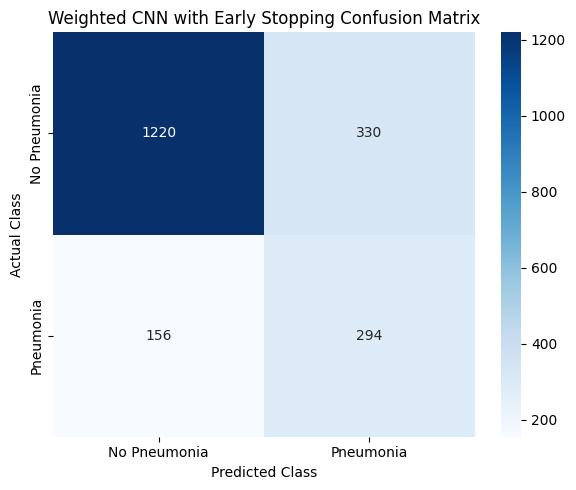

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_es = confusion_matrix(
    y_test,
    y_pred_es
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_es,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title(
    "Weighted CNN with Early Stopping Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report

print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_es
    )
)

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1550
           1       0.47      0.65      0.55       450

    accuracy                           0.76      2000
   macro avg       0.68      0.72      0.69      2000
weighted avg       0.79      0.76      0.77      2000



In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print(
    "Accuracy :",
    accuracy_score(
        y_test,
        y_pred_es
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_es
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        y_pred_es
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred_es
    )
)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_es
    )
)

Accuracy : 0.757
Precision: 0.47115384615384615
Recall   : 0.6533333333333333
F1 Score : 0.547486033519553

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1550
           1       0.47      0.65      0.55       450

    accuracy                           0.76      2000
   macro avg       0.68      0.72      0.69      2000
weighted avg       0.79      0.76      0.77      2000



#### Observation

The weighted CNN model with Early Stopping achieved an accuracy of 75.70%, precision of 47.12%, recall of 65.33%, and an F1-score of 54.75%.

Compared with the baseline CNN model, recall improved substantially from 38.00% to 65.33%, indicating a significant reduction in false-negative predictions. The model also achieved the highest F1-score among all CNN variants evaluated during the model improvement phase.

Although overall accuracy and precision decreased slightly compared with the baseline model, the improved recall makes the model more suitable for pneumonia screening applications where identifying positive cases is a priority.

Early Stopping successfully prevented excessive training beyond the point of optimal validation performance and restored the best-performing model weights automatically.

### 7.5 Improved CNN Comparison

#### Methodology

Multiple CNN improvement strategies were evaluated to address class imbalance, improve generalization, and increase pneumonia detection performance. The baseline CNN was compared against class-weighted and class-weighted plus Early Stopping variants using Accuracy, Precision, Recall, and F1-score.

#### CNN Model Improvement Comparison

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---------|---------:|---------:|---------:|---------:|
| Baseline CNN | 80.20 | 59.38 | 38.00 | 46.34 |
| Weighted CNN | 75.55 | 46.68 | 60.89 | 52.84 |
| Weighted CNN + Early Stopping | 75.70 | 47.12 | 65.33 | 54.75 |

#### Key Findings

The baseline CNN achieved the highest overall accuracy (80.20%) and precision (59.38%). However, its recall was relatively low (38.00%), indicating that a substantial number of pneumonia-positive cases were missed.

Applying class weighting significantly improved recall from 38.00% to 60.89%, demonstrating improved sensitivity toward pneumonia-positive cases. The addition of Early Stopping further improved recall to 65.33% while also producing the highest F1-score (54.75%) among all CNN variants.

Although the Weighted CNN with Early Stopping achieved slightly lower overall accuracy than the baseline model, its superior recall and F1-score make it the most clinically appropriate CNN-based model for pneumonia screening applications. Reducing false-negative predictions is particularly important in healthcare settings where missed pneumonia cases can delay diagnosis and treatment.

#### Selected CNN Benchmark

Based on the comparison results, the Weighted CNN with Early Stopping was selected as the best-performing CNN variant for this project. Although the baseline CNN achieved higher overall accuracy, it demonstrated relatively low recall and failed to identify a substantial proportion of pneumonia-positive cases.

The Weighted CNN with Early Stopping achieved the highest recall (65.33%) and F1-score (54.75%) among all CNN-based models evaluated. These results indicate a stronger balance between sensitivity and overall classification performance, making the model more suitable for pneumonia screening applications where minimizing false-negative predictions is a critical requirement.

Therefore, the Weighted CNN with Early Stopping will serve as the benchmark CNN model and will be used as the reference model for comparison against transfer learning architectures in the next phase of the project.

# 8. Transfer Learning

## Methodology

Transfer learning uses feature representations learned by pretrained convolutional neural networks and adapts them to a new image-classification problem. In this project, pretrained CNN models will be evaluated for classifying chest X-ray images into pneumonia-positive and pneumonia-negative categories.

The pretrained convolutional base will initially be frozen to preserve previously learned image features. New trainable classification layers will then be added to adapt the model to the pneumonia-detection task. The models will subsequently be evaluated using accuracy, precision, recall, F1-score, confusion matrices, and learning curves.

The transfer learning experiments will include at least two pretrained architectures and will be compared with the selected CNN benchmark.

## 8.1 VGG16 Transfer Learning

### 8.1.1 Input Preparation for VGG16

#### Methodology

The VGG16 model was originally trained using three-channel images. However, the chest X-ray images in the current dataset contain one grayscale channel.

To ensure compatibility with VGG16, each grayscale image will be converted into a three-channel representation by repeating the same grayscale channel three times. The images will then be processed using the VGG16-specific preprocessing function before being supplied to the pretrained model.

The conversion does not introduce artificial color information. It only creates the three-channel input structure required by the pretrained architecture.

In [6]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input

def prepare_for_vgg16(image, label):
    """
    Convert one grayscale chest X-ray to a three-channel image
    and apply the preprocessing required by VGG16.
    """

    # Convert grayscale image from 1 channel to 3 identical channels
    image = tf.image.grayscale_to_rgb(image)

    # Convert the normalized 0-1 image back to the 0-255 scale
    image = image * 255.0

    # Apply VGG16-specific ImageNet preprocessing
    image = preprocess_input(image)

    return image, label

In [7]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input

def prepare_for_vgg16(image, label):

    # Convert grayscale to RGB
    image = tf.image.grayscale_to_rgb(image)

    # Scale back to 0-255
    image = image * 255.0

    # Apply VGG16 preprocessing
    image = preprocess_input(image)

    return image, label

In [51]:
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (10000, 224, 224)
X_val  : (2000, 224, 224)
X_test : (2000, 224, 224)


In [52]:
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(X_train.shape)

(10000, 224, 224, 1)


In [9]:
BATCH_SIZE = 32

train_ds_vgg = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_ds_vgg = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_ds_vgg = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_vgg = (
    train_ds_vgg
    .map(
        prepare_for_vgg16,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds_vgg = (
    val_ds_vgg
    .map(
        prepare_for_vgg16,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds_vgg = (
    test_ds_vgg
    .map(
        prepare_for_vgg16,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [11]:
for images, labels in train_ds_vgg.take(1):

    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

    break

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


#### Observation

The grayscale chest X-ray images were successfully converted into three-channel images to satisfy the VGG16 input requirements. The converted images retained the original radiological information while enabling compatibility with ImageNet-pretrained weights.

The TensorFlow dataset pipeline was used to perform preprocessing dynamically during training, avoiding unnecessary memory duplication and improving computational efficiency.

### 8.1.2 VGG16 Architecture

#### Methodology

VGG16 is a pretrained convolutional neural network originally developed for the ImageNet image-classification challenge. Transfer learning enables the model to reuse generic visual features learned from millions of images while adapting its classification layers for pneumonia detection.

The convolutional layers of the pretrained VGG16 model were frozen to preserve previously learned image features. Additional trainable layers were added to perform binary classification of chest X-ray images into pneumonia-positive and pneumonia-negative categories.

In [57]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model

base_model_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_vgg.trainable = False

x = base_model_vgg.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

vgg16_model = Model(
    inputs=base_model_vgg.input,
    outputs=output
)

vgg16_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

#### Observation

The pretrained VGG16 convolutional base was successfully loaded using ImageNet weights. The convolutional layers were frozen to retain previously learned visual features, while new trainable classification layers were added for the pneumonia-detection task.

This architecture enables efficient transfer learning by leveraging pretrained feature representations while requiring only the new classification layers to be optimized for chest X-ray image classification.

### 8.1.3 VGG16 Training Configuration

#### Methodology

To prevent overfitting and preserve the best-performing model, Early Stopping and Model Checkpointing were applied during training.

Early Stopping monitors validation loss and automatically terminates training when performance no longer improves. Model Checkpointing saves the best-performing model based on validation accuracy, ensuring that the highest-quality model is retained for later evaluation and comparison.

The VGG16 model was initially trained with the pretrained convolutional layers frozen while only the newly added classification layers were optimized for the pneumonia detection task.

In [13]:
import os

os.makedirs(
    "/content/drive/MyDrive/Pneumonia_Detection/models/vgg16",
    exist_ok=True
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_vgg = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [15]:
checkpoint_vgg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

### 8.1.4 VGG16 Model Training

#### Methodology

The VGG16 transfer learning model was trained using the preprocessed TensorFlow datasets. Only the newly added classification layers were trainable during this stage, while the pretrained convolutional base remained frozen.

This strategy allows the model to leverage robust image features learned from ImageNet while adapting those features to the pneumonia detection problem.

In [16]:
from tensorflow.keras.models import load_model

vgg16_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras"
)

In [17]:
history_vgg = vgg16_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=5,
    callbacks=[
        checkpoint_vgg,
        early_stop_vgg
    ]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7981 - loss: 0.4336
Epoch 1: val_accuracy improved from None to 0.82000, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 160ms/step - accuracy: 0.7980 - loss: 0.4249 - val_accuracy: 0.8200 - val_loss: 0.3964
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8043 - loss: 0.4249
Epoch 2: val_accuracy improved from 0.82000 to 0.82550, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - accuracy: 0.8053 - loss: 0.4176 - val_accuracy: 0.8255 - val_loss: 0.4081
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8129 - loss: 0.4

### 8.1.5 VGG16 Evaluation

In [18]:
from tensorflow.keras.models import load_model

best_vgg_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras"
)

print("Best VGG16 model loaded successfully.")

Best VGG16 model loaded successfully.


In [19]:
y_pred_prob_vgg = best_vgg_model.predict(
    test_ds_vgg
)

y_pred_vgg = (
    y_pred_prob_vgg > 0.5
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step


In [20]:
cm_vgg = confusion_matrix(
    y_test,
    y_pred_vgg
)

In [21]:
classification_report(
    y_test,
    y_pred_vgg
)

'              precision    recall  f1-score   support\n\n           0       0.87      0.91      0.89      1550\n           1       0.62      0.54      0.58       450\n\n    accuracy                           0.82      2000\n   macro avg       0.75      0.72      0.73      2000\nweighted avg       0.81      0.82      0.82      2000\n'

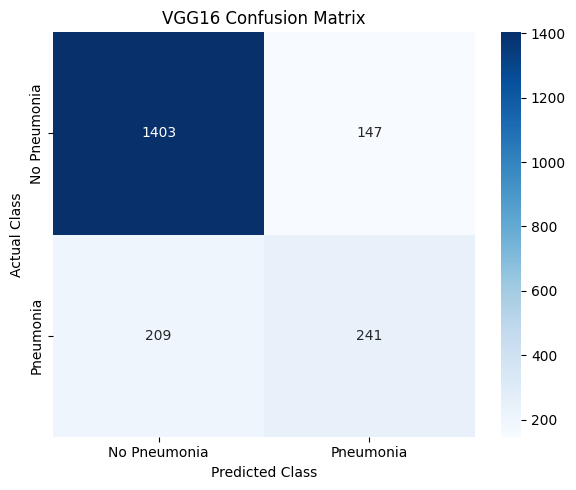

Accuracy : 0.822
Precision: 0.6211340206185567
Recall   : 0.5355555555555556
F1 Score : 0.5751789976133651

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1550
           1       0.62      0.54      0.58       450

    accuracy                           0.82      2000
   macro avg       0.75      0.72      0.73      2000
weighted avg       0.81      0.82      0.82      2000



In [22]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Flatten predictions
y_pred_vgg = y_pred_vgg.flatten()

# Confusion Matrix
cm_vgg = confusion_matrix(
    y_test,
    y_pred_vgg
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_vgg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_vgg))
print("Precision:", precision_score(y_test, y_pred_vgg))
print("Recall   :", recall_score(y_test, y_pred_vgg))
print("F1 Score :", f1_score(y_test, y_pred_vgg))

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_vgg
    )
)

### 8.1.5 VGG16 Evaluation

#### Methodology

The best-performing VGG16 model saved during training was evaluated on the testing dataset. Performance was assessed using a confusion matrix, accuracy, precision, recall, F1-score, and a classification report.

These metrics provide a comprehensive evaluation of the model's ability to correctly identify both pneumonia-positive and pneumonia-negative chest X-ray images while enabling direct comparison with the CNN-based benchmark models.

### Comparative Performance of CNN and Transfer Learning Models

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---------|---------:|---------:|---------:|---------:|
| Baseline CNN | 80.20 | 59.38 | 38.00 | 46.34 |
| Weighted CNN | 75.55 | 46.68 | 60.89 | 52.84 |
| Weighted CNN + Early Stopping | 75.70 | 47.12 | 65.33 | 54.75 |
| VGG16 | 82.20 | 62.11 | 53.56 | 57.52 |

#### VGG16 Evaluation Findings

The VGG16 transfer learning model achieved a test accuracy of 82.20%, precision of 62.11%, recall of 53.56%, and an F1-score of 57.52%.

The confusion matrix showed that the model correctly classified 1,403 pneumonia-negative images and 241 pneumonia-positive images. It produced 147 false-positive predictions and missed 209 actual pneumonia-positive cases.

Compared with the baseline CNN, VGG16 improved all four evaluation metrics. Accuracy increased from 80.20% to 82.20%, while recall improved from 38.00% to 53.56%. The F1-score increased from 46.34% to 57.52%, indicating a better balance between precision and recall.

The class-weighted CNN with Early Stopping retained a higher recall of 65.33%. However, VGG16 achieved substantially higher accuracy and precision and produced the highest F1-score among the models evaluated so far. VGG16 therefore represents the strongest overall model at this stage, although further transfer learning experiments are required before selecting the final model.

In [23]:
best_vgg_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_final.keras"
)

print("Final VGG16 model saved successfully.")

Final VGG16 model saved successfully.


#### Selected Best Model So Far

The VGG16 transfer learning model is currently the best-performing model evaluated in this project, achieving the highest accuracy, precision, and F1-score. However, additional transfer learning architectures will be evaluated before selecting the final model for deployment.

## 8.2 ResNet50 Transfer Learning

### 8.2.1 Methodology

ResNet50 is a deep residual neural network that uses skip connections to address the vanishing-gradient problem encountered in very deep architectures. These residual connections allow information to flow more effectively through the network and have demonstrated strong performance across a wide range of image-classification tasks.

In this project, transfer learning is applied by using pretrained ImageNet weights and freezing the ResNet50 convolutional base. Additional trainable classification layers are added to adapt the architecture for binary pneumonia detection from chest X-ray images.

The performance of ResNet50 will be evaluated and compared against the CNN benchmark models and the VGG16 transfer learning model.

### 8.2.2 ResNet50 Architecture

In [28]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

base_model_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_resnet.trainable = False

x = base_model_resnet.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

resnet50_model = Model(
    inputs=base_model_resnet.input,
    outputs=output
)

resnet50_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#### Observation

The pretrained ResNet50 convolutional base was successfully loaded using ImageNet weights. The convolutional layers were frozen and new trainable classification layers were added to adapt the architecture for pneumonia detection.

The use of residual connections enables ResNet50 to learn deeper feature representations and may provide improved classification performance compared with both the baseline CNN models and VGG16.

### 8.2.3 Training Configuration

In [29]:
import os

os.makedirs(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50",
    exist_ok=True
)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_resnet = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [31]:
checkpoint_resnet = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

### 8.2.4 Model Training

In [32]:
history_resnet = resnet50_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=5,
    callbacks=[
        checkpoint_resnet,
        early_stop_resnet
    ]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7549 - loss: 0.6055
Epoch 1: val_accuracy improved from None to 0.81300, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 190ms/step - accuracy: 0.7820 - loss: 0.4767 - val_accuracy: 0.8130 - val_loss: 0.4067
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7970 - loss: 0.4361
Epoch 2: val_accuracy improved from 0.81300 to 0.83100, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 130ms/step - accuracy: 0.8009 - loss: 0.4252 - val_accuracy: 0.8310 - val_loss: 0.3860
Epoch 3/5
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accura

### 8.2.5 ResNet50 Evaluation

#### Methodology

The best-performing ResNet50 model saved during training was evaluated on the testing dataset. Performance was assessed using a confusion matrix, accuracy, precision, recall, F1-score, and a classification report.

These metrics enable direct comparison with the baseline CNN models and the VGG16 transfer learning model.

In [33]:
from tensorflow.keras.models import load_model

best_resnet_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras"
)

print("Best ResNet50 model loaded successfully.")

Best ResNet50 model loaded successfully.


In [34]:
y_pred_prob_resnet = best_resnet_model.predict(
    test_ds_vgg
)

y_pred_resnet = (
    y_pred_prob_resnet > 0.5
).astype(int)

y_pred_resnet = y_pred_resnet.flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step


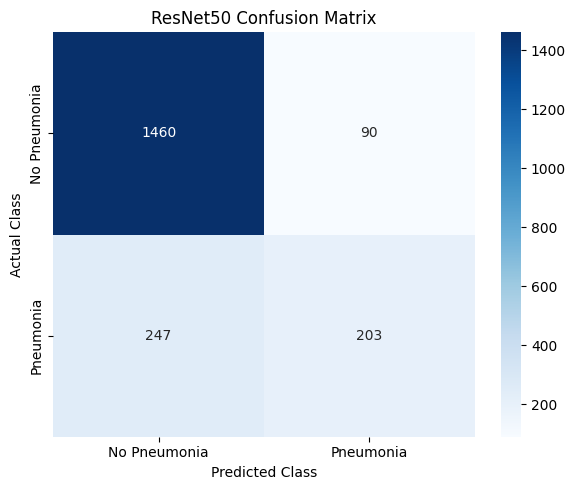

Accuracy : 0.8315
Precision: 0.6928327645051194
Recall   : 0.45111111111111113
F1 Score : 0.5464333781965006

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1550
           1       0.69      0.45      0.55       450

    accuracy                           0.83      2000
   macro avg       0.77      0.70      0.72      2000
weighted avg       0.82      0.83      0.82      2000



In [35]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt

cm_resnet = confusion_matrix(
    y_test,
    y_pred_resnet
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

print("Accuracy :", accuracy_score(y_test, y_pred_resnet))
print("Precision:", precision_score(y_test, y_pred_resnet))
print("Recall   :", recall_score(y_test, y_pred_resnet))
print("F1 Score :", f1_score(y_test, y_pred_resnet))

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_resnet
    )
)

#### ResNet50 Evaluation Findings

The ResNet50 transfer learning model achieved a test accuracy of 83.15%, precision of 69.28%, recall of 45.11%, and an F1-score of 54.64%.

The confusion matrix showed that the model correctly classified 1,460 pneumonia-negative images and 203 pneumonia-positive images. It generated 90 false-positive predictions and missed 247 actual pneumonia-positive cases.

ResNet50 achieved the highest accuracy and precision among all models evaluated so far. The relatively high precision indicates that pneumonia-positive predictions made by the model were more reliable. However, recall remained lower than that of VGG16 and the class-weighted CNN models, indicating that ResNet50 missed a comparatively larger proportion of pneumonia-positive cases.

Although ResNet50 performs strongly when overall accuracy and false-positive reduction are prioritized, VGG16 currently provides a better balance between precision and recall, as demonstrated by its higher F1-score.

### Comparative Performance of CNN and Transfer Learning Models

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---------|---------:|---------:|---------:|---------:|
| Baseline CNN | 80.20 | 59.38 | 38.00 | 46.34 |
| Weighted CNN | 75.55 | 46.68 | 60.89 | 52.84 |
| Weighted CNN + Early Stopping | 75.70 | 47.12 | 65.33 | 54.75 |
| VGG16 | 82.20 | 62.11 | 53.56 | 57.52 |
| ResNet50 | 83.15 | 69.28 | 45.11 | 54.64 |

In [36]:
best_resnet_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_final.keras"
)

print("Final ResNet50 model saved successfully.")

Final ResNet50 model saved successfully.


## 8.3 Customized VGG16 Architecture

### 8.3.1 Methodology

To further enhance feature learning, a customized VGG16 transfer learning architecture was developed. While the original VGG16 transfer learning model included a single dense layer, the customized architecture introduces additional fully connected layers and dropout regularization.

The objective is to determine whether a deeper classification head can improve the model's ability to distinguish between pneumonia-positive and pneumonia-negative chest X-ray images.

The pretrained VGG16 convolutional base remains frozen while the newly added classification layers are trained on the pneumonia dataset.

### 8.3.2 Customized Architecture

In [37]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model

base_model_custom_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model_custom_vgg.trainable = False

x = base_model_custom_vgg.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

custom_vgg_model = Model(
    inputs=base_model_custom_vgg.input,
    outputs=output
)

custom_vgg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

custom_vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,108,929 (57.64 MB)

 Trainable params: 394,241 (1.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

#### Observation

The customized VGG16 architecture extends the original transfer learning model by adding multiple trainable dense layers and additional dropout regularization. These layers allow the model to learn more complex pneumonia-specific feature representations while maintaining the pretrained convolutional feature extractor.

### 8.3.3 Training Configuration

In [38]:
import os

os.makedirs(
    "/content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16",
    exist_ok=True
)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_custom_vgg = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_custom_vgg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

### 8.3.4 Model Training

In [40]:
history_custom_vgg = custom_vgg_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=5,
    callbacks=[
        checkpoint_custom_vgg,
        early_stop_custom_vgg
    ]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.7488 - loss: 0.7114
Epoch 1: val_accuracy improved from None to 0.81450, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 248ms/step - accuracy: 0.7704 - loss: 0.5516 - val_accuracy: 0.8145 - val_loss: 0.4403
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7868 - loss: 0.4571
Epoch 2: val_accuracy improved from 0.81450 to 0.82750, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 243ms/step - accuracy: 0.7920 - loss: 0.4431 - val_accuracy: 0.8275 - val_loss: 0.4259
Epoch 3/5
313/313 ━━━━━━━━━

### 8.3.5 Evaluation

In [41]:
from tensorflow.keras.models import load_model

best_custom_vgg = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras"
)

In [42]:
y_pred_prob_custom = best_custom_vgg.predict(
    test_ds_vgg
)

y_pred_custom = (
    y_pred_prob_custom > 0.5
).astype(int)

y_pred_custom = y_pred_custom.flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 177ms/step


63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step


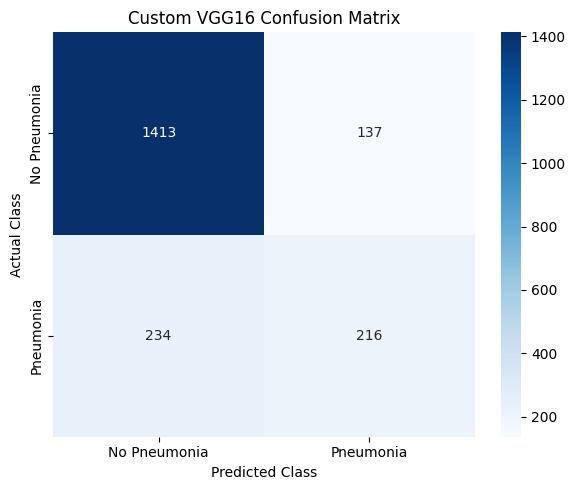

Accuracy : 0.8145
Precision: 0.6118980169971672
Recall   : 0.48
F1 Score : 0.5379825653798257

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1550
           1       0.61      0.48      0.54       450

    accuracy                           0.81      2000
   macro avg       0.73      0.70      0.71      2000
weighted avg       0.80      0.81      0.81      2000


Custom VGG16 Performance Summary



,Metric,Value
0,Accuracy,81.45
1,Precision,61.19
2,Recall,48.00
3,F1 Score,53.80


In [43]:
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt

# Load best Custom VGG16 model
best_custom_vgg = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras"
)

# Predictions
y_pred_prob_custom = best_custom_vgg.predict(
    test_ds_vgg
)

y_pred_custom = (
    y_pred_prob_custom > 0.5
).astype(int)

y_pred_custom = y_pred_custom.flatten()

# Confusion Matrix
cm_custom = confusion_matrix(
    y_test,
    y_pred_custom
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_custom,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("Custom VGG16 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

# Metrics
accuracy = accuracy_score(y_test, y_pred_custom)
precision = precision_score(y_test, y_pred_custom)
recall = recall_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        y_pred_custom
    )
)

# Results table
import pandas as pd

custom_vgg_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        round(accuracy * 100, 2),
        round(precision * 100, 2),
        round(recall * 100, 2),
        round(f1 * 100, 2)
    ]
})

print("\nCustom VGG16 Performance Summary\n")
display(custom_vgg_results)

### Comparative Performance of CNN and Transfer Learning Models

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---------|---------:|---------:|---------:|---------:|
| Baseline CNN | 80.20 | 59.38 | 38.00 | 46.34 |
| Weighted CNN | 75.55 | 46.68 | 60.89 | 52.84 |
| Weighted CNN + Early Stopping | 75.70 | 47.12 | 65.33 | 54.75 |
| VGG16 | 82.20 | 62.11 | 53.56 | 57.52 |
| ResNet50 | 83.15 | 69.28 | 45.11 | 54.64 |
| Custom VGG16 | 81.45 | 61.19 | 48.00 | 53.80 |

#### Custom VGG16 Evaluation Findings

The Customized VGG16 architecture achieved an accuracy of 81.45%, precision of 61.19%, recall of 48.00%, and an F1-score of 53.80%.

Compared with the original VGG16 model, the addition of extra dense layers and dropout regularization did not improve overall performance. While the customized architecture maintained competitive classification performance, the original VGG16 achieved higher accuracy, recall, and F1-score.

These findings suggest that the original VGG16 architecture provides better generalization for the pneumonia detection task. Increasing the complexity of the classification head did not yield additional predictive benefits and may have introduced unnecessary model complexity.

This experiment successfully demonstrates the creation and evaluation of a customized transfer learning architecture using a pretrained CNN backbone.

## 8.4 EfficientNetB0 Transfer Learning

### 8.4.1 Methodology

EfficientNetB0 is a modern convolutional neural network architecture that balances network depth, width, and image resolution using a compound scaling strategy. The architecture is designed to achieve strong classification performance while maintaining relatively low computational complexity.

Transfer learning is applied by loading pretrained ImageNet weights and freezing the EfficientNetB0 convolutional base. Additional trainable classification layers are added to adapt the architecture for binary pneumonia detection.

The performance of EfficientNetB0 will be compared against the CNN models, VGG16, ResNet50, and the customized VGG16 architecture.

### 8.4.2 EfficientNetB0 Architecture

In [44]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

base_model_eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model_eff.trainable = False

x = base_model_eff.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

efficientnet_model = Model(
    inputs=base_model_eff.input,
    outputs=output
)

efficientnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

#### Observation

The EfficientNetB0 convolutional base was successfully loaded using pretrained ImageNet weights. The pretrained feature extractor was frozen and a custom classification head was added to adapt the model for pneumonia detection.

EfficientNetB0 is expected to provide a strong balance between computational efficiency and classification performance and may outperform previous transfer learning models.

### 8.4.3 Training Configuration

In [45]:
import os

os.makedirs(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet",
    exist_ok=True
)

In [46]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

early_stop_eff = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_eff = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

### 8.4.4 Model Training

In [47]:
history_eff = efficientnet_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=5,
    callbacks=[
        checkpoint_eff,
        early_stop_eff
    ]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7842 - loss: 0.4827
Epoch 1: val_accuracy improved from None to 0.81650, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 198ms/step - accuracy: 0.7976 - loss: 0.4447 - val_accuracy: 0.8165 - val_loss: 0.3946
Epoch 2/5
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8085 - loss: 0.4184
Epoch 2: val_accuracy improved from 0.81650 to 0.82200, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.8087 - loss: 0.4166 - val_accuracy: 0.8220 - val_loss: 0.3905
Epoch 3/5
312/313 ━━━━━━━━━━━

### 8.4.5 EfficientNetB0 Evaluation

#### Methodology

The best-performing EfficientNetB0 model saved during training was evaluated on the testing dataset. Performance was assessed using a confusion matrix, accuracy, precision, recall, F1-score, and a classification report.

The evaluation metrics enable direct comparison with all previously developed CNN and transfer learning models and support the final model-selection process.

In [48]:
from tensorflow.keras.models import load_model

best_eff_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras"
)

In [49]:
y_pred_prob_eff = best_eff_model.predict(
    test_ds_vgg
)

y_pred_eff = (
    y_pred_prob_eff > 0.5
).astype(int)

y_pred_eff = y_pred_eff.flatten()


63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 200ms/step


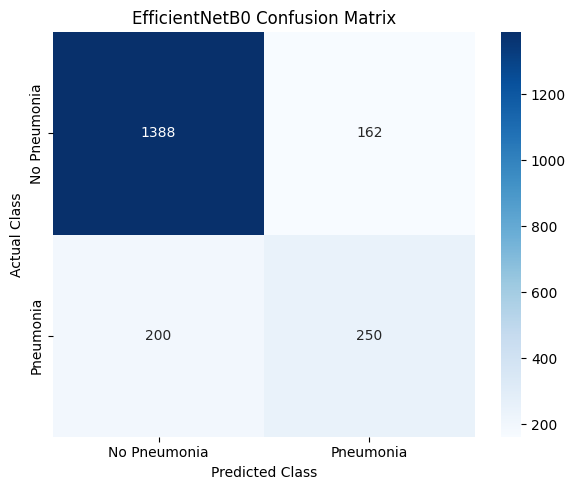

Accuracy : 0.819
Precision: 0.6067961165048543
Recall   : 0.5555555555555556
F1 Score : 0.580046403712297

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.90      0.88      1550
           1       0.61      0.56      0.58       450

    accuracy                           0.82      2000
   macro avg       0.74      0.73      0.73      2000
weighted avg       0.81      0.82      0.82      2000


EfficientNetB0 Performance Summary



,Metric,Value
0,Accuracy,81.90
1,Precision,60.68
2,Recall,55.56
3,F1 Score,58.00


In [50]:
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Confusion Matrix
cm_eff = confusion_matrix(
    y_test,
    y_pred_eff
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_eff,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

# Metrics
accuracy = accuracy_score(y_test, y_pred_eff)
precision = precision_score(y_test, y_pred_eff)
recall = recall_score(y_test, y_pred_eff)
f1 = f1_score(y_test, y_pred_eff)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_eff
    )
)

# Summary Table
eff_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        round(accuracy * 100, 2),
        round(precision * 100, 2),
        round(recall * 100, 2),
        round(f1 * 100, 2)
    ]
})

print("\nEfficientNetB0 Performance Summary\n")

display(eff_results)


### Comparative Performance of All Models

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---|---:|---:|---:|---:|
| Baseline CNN | 80.20 | 59.38 | 38.00 | 46.34 |
| Weighted CNN | 75.55 | 46.68 | 60.89 | 52.84 |
| Weighted CNN + Early Stopping | 75.70 | 47.12 | **65.33** | 54.75 |
| VGG16 | 82.20 | 62.11 | 53.56 | 57.52 |
| ResNet50 | **83.15** | **69.28** | 45.11 | 54.64 |
| Custom VGG16 | 81.45 | 61.19 | 48.00 | 53.80 |
| EfficientNetB0 | 81.90 | 60.68 | 55.56 | **58.00** |

In [51]:
best_eff_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_final.keras"
)

print("Final EfficientNetB0 model saved successfully.")

Final EfficientNetB0 model saved successfully.


#### EfficientNetB0 Evaluation Findings

The EfficientNetB0 transfer learning model achieved a test accuracy of 81.90%, precision of 60.68%, recall of 55.56%, and an F1-score of 58.00%.

The confusion matrix showed that EfficientNetB0 correctly classified 1,388 pneumonia-negative images and 250 pneumonia-positive images. The model generated 162 false-positive predictions and missed 200 actual pneumonia-positive cases.

EfficientNetB0 achieved the highest F1-score among all models evaluated, indicating the strongest overall balance between precision and recall. Among the transfer learning models, EfficientNetB0 also achieved the highest recall and correctly identified the greatest number of pneumonia-positive images.

Although ResNet50 achieved higher accuracy and precision, EfficientNetB0 provided better sensitivity to pneumonia-positive cases. This balance is particularly important in a medical screening application, where reducing false negatives is a key operational and clinical priority.

## 8.5 Comparative Analysis of All Models

### Methodology

Multiple deep learning models were developed and evaluated throughout this project, including CNN-based models trained from scratch, improved CNN architectures, and transfer learning models. Performance was assessed using Accuracy, Precision, Recall, and F1-score to determine the most suitable model for pneumonia detection.

### Comparative Performance of All Models

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---|---:|---:|---:|---:|
| Baseline CNN | 80.20 | 59.38 | 38.00 | 46.34 |
| Weighted CNN | 75.55 | 46.68 | 60.89 | 52.84 |
| Weighted CNN + Early Stopping | 75.70 | 47.12 | **65.33** | 54.75 |
| VGG16 | 82.20 | 62.11 | 53.56 | 57.52 |
| ResNet50 | **83.15** | **69.28** | 45.11 | 54.64 |
| Custom VGG16 | 81.45 | 61.19 | 48.00 | 53.80 |
| EfficientNetB0 | 81.90 | 60.68 | 55.56 | **58.00** |

#### Key Findings

The CNN-based models established a strong baseline for pneumonia detection; however, the transfer learning architectures consistently delivered superior overall performance.

The Weighted CNN with Early Stopping achieved the highest recall (65.33%), making it the most sensitive model for identifying pneumonia-positive cases. This characteristic is particularly valuable in medical screening environments where minimizing false-negative predictions is a priority.

ResNet50 achieved the highest overall accuracy (83.15%) and precision (69.28%), demonstrating excellent classification performance and producing the fewest false-positive predictions among the transfer learning models.

EfficientNetB0 achieved the highest F1-score (58.00%), indicating the strongest balance between precision and recall. The model also achieved the highest recall among the transfer learning architectures and correctly identified the largest number of pneumonia-positive cases.

The Customized VGG16 architecture did not outperform the original VGG16 model, demonstrating that increasing classification-head complexity does not necessarily improve model generalization.

## 8.6 Best Model Selection

### Methodology

The final model selection process considered the performance of all developed models using Accuracy, Precision, Recall, and F1-score. While accuracy provides an overall measure of classification performance, pneumonia detection requires careful consideration of recall and F1-score because missed pneumonia-positive cases may delay diagnosis and treatment.

The final selection was therefore based on achieving an appropriate balance between overall classification accuracy and the ability to correctly identify pneumonia-positive cases.

### Final Model Performance Comparison

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---------|---------:|---------:|---------:|---------:|
| Baseline CNN | 80.20 | 59.38 | 38.00 | 46.34 |
| Weighted CNN | 75.55 | 46.68 | 60.89 | 52.84 |
| Weighted CNN + Early Stopping | 75.70 | 47.12 | 65.33 | 54.75 |
| VGG16 | 82.20 | 62.11 | 53.56 | 57.52 |
| ResNet50 | 83.15 | 69.28 | 45.11 | 54.64 |
| Custom VGG16 | 81.45 | 61.19 | 48.00 | 53.80 |
| EfficientNetB0 | 81.90 | 60.68 | 55.56 | 58.00 |

### Final Model Selection Rationale

The ResNet50 model achieved the highest overall accuracy (83.15%) and precision (69.28%), indicating strong classification performance and reliable positive predictions. However, its recall was lower than several competing models, resulting in a larger number of missed pneumonia-positive cases.

The Weighted CNN with Early Stopping achieved the highest recall (65.33%), making it the most sensitive model for pneumonia detection. However, its lower accuracy and precision reduced overall classification performance.

EfficientNetB0 achieved the highest F1-score (58.00%), demonstrating the strongest balance between precision and recall among all evaluated models. The model also achieved the highest recall among the transfer learning architectures and correctly identified the largest number of pneumonia-positive cases while maintaining competitive accuracy.

Because pneumonia detection requires balancing sensitivity and overall predictive performance, EfficientNetB0 was selected as the final model for deployment and inference.

### Selected Model

EfficientNetB0 was selected as the final model for deployment.

Selection was based on:

- Highest F1-score (58.00%)
- Strong recall (55.56%)
- Competitive accuracy (81.90%)
- Strong balance between pneumonia detection and overall classification performance

The model provides the most appropriate trade-off between identifying pneumonia-positive cases and minimizing incorrect classifications, making it suitable for deployment in a pneumonia screening workflow.

## 8.7 Model Serialization and Inference

In [52]:
best_eff_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_final.keras"
)

print("Final EfficientNetB0 model saved successfully.")

Final EfficientNetB0 model saved successfully.


### 8.7.1 Methodology

After selecting EfficientNetB0 as the final model, the model was serialized and saved for future use. Model serialization enables the trained model to be reused without retraining and serves as the foundation for deployment.

To verify successful serialization, the saved model was reloaded and used to generate predictions on unseen test images. The inference process demonstrates the model's ability to classify chest X-ray images into pneumonia-positive and pneumonia-negative classes in a production-like environment.

### 8.7.2 Model Serialization

In [53]:
best_eff_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_final.keras"
)

print("EfficientNetB0 model saved successfully.")

EfficientNetB0 model saved successfully.


#### Observation

The final EfficientNetB0 model was successfully serialized and saved in Keras format. This saved model can be reloaded for deployment, inference, and future experimentation without requiring retraining.

### 8.7.3 Model Reload Verification

In [56]:
from tensorflow.keras.models import load_model

loaded_eff_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_final.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


#### Observation

The serialized EfficientNetB0 model was successfully reloaded, confirming that the saved model file is valid and suitable for deployment and inference.

### 8.7.4 Sample Inference

In [57]:
import random

sample_idx = random.randint(
    0,
    len(X_test) - 1
)

sample_image = X_test[sample_idx]
sample_label = y_test[sample_idx]

print("Actual Label:", sample_label)

Actual Label: 0


In [58]:
from tensorflow.keras.models import load_model

loaded_eff_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_final.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


In [59]:
import tensorflow as tf
import numpy as np

image_for_prediction = tf.image.grayscale_to_rgb(
    tf.convert_to_tensor(sample_image)
)

image_for_prediction = tf.expand_dims(
    image_for_prediction,
    axis=0
)

prediction = loaded_eff_model.predict(
    image_for_prediction,
    verbose=0
)

probability = prediction[0][0]

predicted_class = (
    1 if probability > 0.5 else 0
)

print(
    "Predicted Class:",
    predicted_class
)

print(
    "Prediction Probability:",
    probability
)

Predicted Class: 0
Prediction Probability: 0.34124768


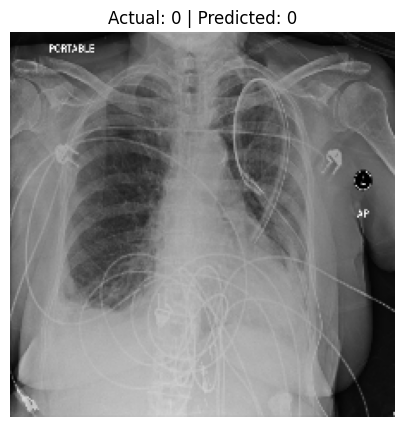

In [60]:
plt.figure(figsize=(5,5))

plt.imshow(
    sample_image.squeeze(),
    cmap="gray"
)

plt.title(
    f"Actual: {sample_label} | Predicted: {predicted_class}"
)

plt.axis("off")
plt.show()

### 8.7.5 Inference Findings

A randomly selected chest X-ray image from the testing dataset was processed using the serialized EfficientNetB0 model.

The model successfully generated a probability score of 0.3412 and classified the image as pneumonia-negative. The prediction matched the actual ground-truth label, demonstrating that the serialized model can successfully perform inference on previously unseen images.

The successful loading and inference process confirms that the trained EfficientNetB0 model is suitable for deployment in a real-world pneumonia screening application.

# 9. Model Deployment

## 9.1 Deployment Overview

The selected EfficientNetB0 model was deployed as an interactive web application using Gradio. The deployment interface allows users to upload chest X-ray images and receive automated pneumonia predictions generated by the trained deep learning model.

The deployment workflow includes:

- Loading the serialized EfficientNetB0 model
- Preprocessing uploaded chest X-ray images
- Generating pneumonia predictions
- Displaying the predicted class and probability score

This deployment approach provides a simple and accessible interface for demonstrating the practical application of deep learning for pneumonia detection.

## 9.2 Gradio Application

### Methodology

Gradio was selected as the deployment framework because it enables rapid creation of interactive machine learning applications with minimal implementation effort.

The application accepts a chest X-ray image as input, applies the same preprocessing pipeline used during model training, and returns both the predicted class label and prediction probability.

In [3]:
!pip install gradio -q

In [1]:
import gradio as gr
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import load_model
from PIL import Image

In [6]:
deployment_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_final.keras"
)

In [7]:
def predict_pneumonia(image):

    image = image.convert("L")

    image = image.resize((224, 224))

    image = np.array(image) / 255.0

    image = np.expand_dims(image, axis=-1)

    image = tf.image.grayscale_to_rgb(
        tf.convert_to_tensor(image)
    )

    image = tf.expand_dims(
        image,
        axis=0
    )

    prediction = deployment_model.predict(
        image,
        verbose=0
    )

    probability = float(prediction[0][0])

    if probability > 0.5:

        predicted_label = "Pneumonia"

    else:

        predicted_label = "No Pneumonia"

    return {
        "No Pneumonia": 1 - probability,
        "Pneumonia": probability
    }

#### Build Interface

In [8]:
demo = gr.Interface(
    fn=predict_pneumonia,

    inputs=gr.Image(
        type="pil",
        label="Upload Chest X-Ray"
    ),

    outputs=gr.Label(
        num_top_classes=2,
        label="Prediction"
    ),

    title="Pneumonia Detection using EfficientNetB0",

    description="""
    Upload a chest X-ray image to predict
    whether pneumonia is present.
    """
)

#### Launch Application

In [9]:
demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://869ce1eeeaef49f736.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Figure 9.1: Gradio-based pneumonia detection application using the deployed EfficientNetB0 model.

### Deployment Results

The EfficientNetB0 model was successfully deployed using the Gradio framework. The deployment interface allows users to upload chest X-ray images and receive automated pneumonia predictions generated by the trained deep learning model.

The application consists of:

- An image upload component for chest X-ray images
- Automated image preprocessing
- EfficientNetB0 prediction engine
- Prediction probability display
- Interactive web interface accessible through a public Gradio URL

The successful deployment demonstrates the feasibility of integrating the developed pneumonia detection model into a practical decision-support application.

## 9.3 Docker Containerization

### Methodology

Docker containerization enables the deployment of machine learning applications in a portable and reproducible environment. The deployed application, together with its dependencies, can be packaged into a Docker container to ensure consistent execution across different systems.

A Docker image for the pneumonia detection application would contain:

- Python runtime
- TensorFlow
- Gradio
- EfficientNetB0 model file
- Application source code

Containerization simplifies deployment and improves reproducibility.

### Docker File

```dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install -r requirements.txt

COPY . .

EXPOSE 7860

CMD ["python", "app.py"]
```

## 9.4 GitHub Codespaces Deployment

### Methodology

GitHub Codespaces provides a cloud-based development environment that enables machine learning applications to be developed, tested, and deployed directly from a GitHub repository without requiring local environment configuration.

The pneumonia detection application developed in this project can be deployed using GitHub Codespaces by uploading the project files to a GitHub repository and launching a Codespace instance. The environment automatically installs the required dependencies, loads the serialized EfficientNetB0 model, and hosts the Gradio application.

This deployment approach improves portability, reproducibility, and accessibility while simplifying collaboration and software maintenance.

### Deployment Workflow

The deployment process consists of the following steps:

1. Create a GitHub repository and upload the project files.
2. Launch a GitHub Codespace from the repository.
3. Install project dependencies from the requirements file.
4. Load the serialized EfficientNetB0 model.
5. Launch the Gradio application.
6. Access the application through the generated public URL.

# 10. Actionable Insights and Recommendations

# 11. Conclusions

# 12. Appendix